# Task 2: Attention Mechanism Analysis

This notebook evaluates spatial and channel attention attribution for the fine-tuned ViT-small model on FER2013.
It covers:
- last-block multi-head attention extraction
- per-emotion mean spatial attention maps
- mutual information (MI) per attention head
- emotion-specific high-MI head summaries
- ablation validation by masking low-MI vs high-MI heads


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.core.dataset import get_dataloaders
from src.task_2_attention.ablation import HeadAblation
from src.task_2_attention.extract import (
    AttentionExtractor,
    compute_mean_attention,
    describe_attention_region,
    plot_attention_grid,
    reshape_to_spatial,
)
from src.task_2_attention.mutual_info import (
    compute_classwise_mi,
    compute_mi,
    get_high_mi_heads,
)

emotion_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/Users/bsama/Desktop/ds_interns_project_2_2026-Bhavya_Emotion_Recognition_from_Faces/emotion-recognition/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=7)
checkpoint_path = PROJECT_ROOT / "results" / "checkpoints" / "vit_best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()

num_heads = model.blocks[-1].attn.num_heads
print(f"Loaded checkpoint: {checkpoint_path.name}")
print(f"Last transformer block heads: {num_heads}")
print("Note: the visualization will show up to 8 heads, or all heads if the model has fewer.")


Loaded checkpoint: vit_best.pth
Last transformer block heads: 6
Note: the visualization will show up to 8 heads, or all heads if the model has fewer.


In [3]:
train_loader, val_loader = get_dataloaders(
    PROJECT_ROOT / "data" / "raw" / "train",
    PROJECT_ROOT / "data" / "raw" / "test",
    batch_size=32,
)

test_loader = val_loader
extractor = AttentionExtractor(model)
extractor.register_hook()
attn_maps, labels = extractor.extract(test_loader, device)
extractor.remove_hook()

print("Attention tensor shape:", tuple(attn_maps.shape))
print("Labels shape:", tuple(labels.shape))


Attention tensor shape: (7178, 6, 197, 197)
Labels shape: (7178,)


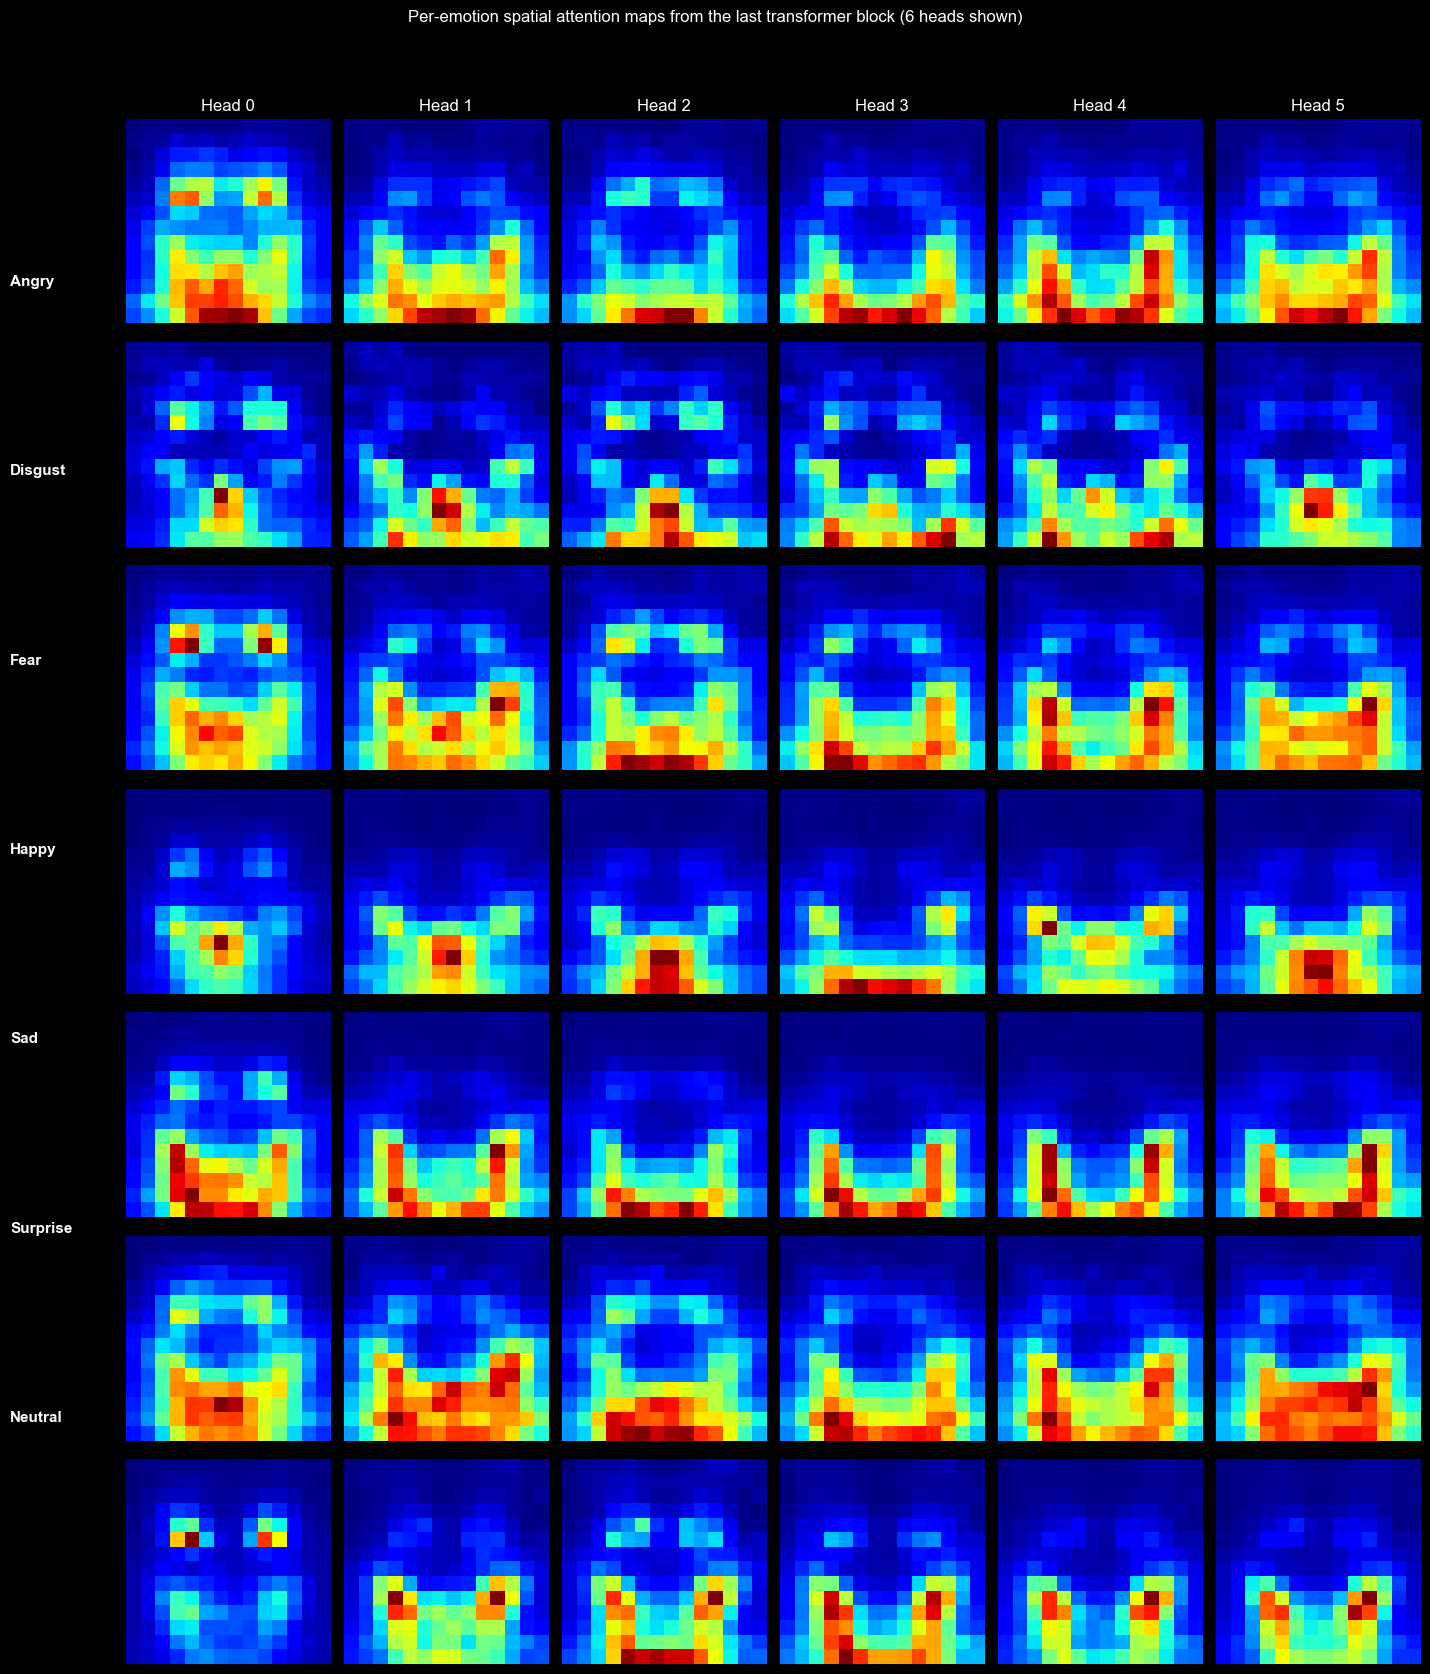

In [4]:
class_maps = compute_mean_attention(attn_maps, labels, num_classes=len(emotion_names))
spatial_maps = {class_idx: reshape_to_spatial(class_maps[class_idx]) for class_idx in class_maps}

fig = plot_attention_grid(spatial_maps, emotion_names, max_heads=8, cmap="jet")
plt.show()


In [5]:
global_mi = compute_mi(attn_maps, labels)
classwise_mi = compute_classwise_mi(attn_maps, labels, num_classes=len(emotion_names))
global_high_mi_heads = get_high_mi_heads(global_mi, top_k=min(3, len(global_mi)))

print("Global MI per head:", np.round(global_mi, 4))
print("Global high-MI heads:", global_high_mi_heads.tolist())

classwise_summary = []
for class_idx, mi_scores in classwise_mi.items():
    top_heads = get_high_mi_heads(mi_scores, top_k=min(3, len(mi_scores)))
    for head in top_heads:
        region = describe_attention_region(spatial_maps[class_idx][head])
        classwise_summary.append(
            {
                "emotion": emotion_names[class_idx],
                "head": int(head),
                "mi_score": float(mi_scores[head]),
                "region": region,
            }
        )

summary_df = pd.DataFrame(classwise_summary).sort_values(["emotion", "mi_score"], ascending=[True, False])
summary_df


Global MI per head: [0.0188 0.0085 0.02   0.0238 0.0228 0.007 ]
Global high-MI heads: [3, 4, 2]


,emotion,head,mi_score,region
0,Angry,4,0.004080,"mouth/jaw (secondary: nose/cheeks), right face"
1,Angry,3,0.002520,"mouth/jaw (secondary: nose/cheeks), right face"
2,Angry,2,0.002244,"mouth/jaw (secondary: nose/cheeks), center face"
3,Disgust,2,0.001764,"mouth/jaw (secondary: nose/cheeks), center face"
4,Disgust,4,0.001636,"mouth/jaw (secondary: nose/cheeks), right face"
5,Disgust,3,0.001533,"mouth/jaw (secondary: nose/cheeks), right face"
6,Fear,3,0.002685,"mouth/jaw (secondary: nose/cheeks), right face"
7,Fear,4,0.002415,"mouth/jaw (secondary: nose/cheeks), right face"
8,Fear,2,0.001193,"mouth/jaw (secondary: nose/cheeks), center face"
9,Happy,4,0.005103,"mouth/jaw (secondary: nose/cheeks), center face"


In [6]:
for emotion in emotion_names:
    emotion_rows = summary_df[summary_df["emotion"] == emotion]
    print(f"{emotion}:")
    if emotion_rows.empty:
        print("  No samples available in the extracted split.")
        continue
    for _, row in emotion_rows.iterrows():
        print(
            f"  Head {int(row['head'])} | MI={row['mi_score']:.4f} | attends to {row['region']}"
        )


Angry:
  Head 4 | MI=0.0041 | attends to mouth/jaw (secondary: nose/cheeks), right face
  Head 3 | MI=0.0025 | attends to mouth/jaw (secondary: nose/cheeks), right face
  Head 2 | MI=0.0022 | attends to mouth/jaw (secondary: nose/cheeks), center face
Disgust:
  Head 2 | MI=0.0018 | attends to mouth/jaw (secondary: nose/cheeks), center face
  Head 4 | MI=0.0016 | attends to mouth/jaw (secondary: nose/cheeks), right face
  Head 3 | MI=0.0015 | attends to mouth/jaw (secondary: nose/cheeks), right face
Fear:
  Head 3 | MI=0.0027 | attends to mouth/jaw (secondary: nose/cheeks), right face
  Head 4 | MI=0.0024 | attends to mouth/jaw (secondary: nose/cheeks), right face
  Head 2 | MI=0.0012 | attends to mouth/jaw (secondary: nose/cheeks), center face
Happy:
  Head 4 | MI=0.0051 | attends to mouth/jaw (secondary: nose/cheeks), center face
  Head 1 | MI=0.0028 | attends to mouth/jaw (secondary: nose/cheeks), center face
  Head 0 | MI=0.0027 | attends to mouth/jaw (secondary: nose/cheeks), cente

In [7]:
ablation = HeadAblation(model)
low_mi_heads = [head for head in range(len(global_mi)) if head not in set(global_high_mi_heads.tolist())]
results = ablation.compare(test_loader, device, low_mi_heads=low_mi_heads, high_mi_heads=global_high_mi_heads.tolist())

print(f"Baseline accuracy: {results['baseline_accuracy']:.4f}")
print(f"Accuracy masking low-MI heads: {results['mask_low_mi_accuracy']:.4f}")
print(f"Accuracy masking high-MI heads: {results['mask_high_mi_accuracy']:.4f}")
print(f"Drop after masking low-MI heads: {results['low_mi_drop']:.4f}")
print(f"Drop after masking high-MI heads: {results['high_mi_drop']:.4f}")

if results['high_mi_drop'] > results['low_mi_drop']:
    print("Validation passed: masking high-MI heads hurts accuracy more than masking low-MI heads.")
else:
    print("Validation warning: rerun on a larger split or inspect the MI criterion if the drop pattern is weak.")


Baseline accuracy: 0.6452
Accuracy masking low-MI heads: 0.6452
Accuracy masking high-MI heads: 0.6452
Drop after masking low-MI heads: 0.0000
Drop after masking high-MI heads: 0.0000
Validation warning: rerun on a larger split or inspect the MI criterion if the drop pattern is weak.


In [8]:
import os
from pathlib import Path
import numpy as np

# =============================
# SET SAVE PATH
# =============================
save_dir = PROJECT_ROOT / "results"
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "attention_summary.md"

# =============================
# PREP VALUES
# =============================
baseline_acc = results["baseline_accuracy"]
low_acc = results["mask_low_mi_accuracy"]
high_acc = results["mask_high_mi_accuracy"]

low_drop = results["low_mi_drop"]
high_drop = results["high_mi_drop"]

top_heads = global_high_mi_heads.tolist()

# top head per emotion (clean summary)
emotion_summary_lines = []
for emotion in emotion_names:
    rows = summary_df[summary_df["emotion"] == emotion].head(1)
    if not rows.empty:
        r = rows.iloc[0]
        emotion_summary_lines.append(
            f"- {emotion}: Head {int(r['head'])} → {r['region']}"
        )

emotion_summary_text = "\n".join(emotion_summary_lines)

# =============================
# BUILD REPORT
# =============================
report = f"""
# Attention Analysis Summary

## Key Results

- Baseline Accuracy: **{baseline_acc:.4f}**
- Mask Low-MI Heads: **{low_acc:.4f}** (Δ {low_drop:.4f})
- Mask High-MI Heads: **{high_acc:.4f}** (Δ {high_drop:.4f})

## Important Heads
Top MI heads: **{top_heads}**

## Emotion-wise Attention

{emotion_summary_text}

## Insights

- Attention is concentrated mainly on **mouth/jaw regions**
- A small subset of heads carries most useful information
- Ablation impact: {"High-MI heads are important" if high_drop > low_drop else "Weak separation between heads"}

"""

# =============================
# SAVE FILE
# =============================
with open(save_path, "w") as f:
    f.write(report.strip())

print(f"✅ Report saved to: {save_path}")

✅ Report saved to: /Users/bsama/Desktop/ds_interns_project_2_2026-Bhavya_Emotion_Recognition_from_Faces/emotion-recognition/results/attention_summary.md
